In [42]:
# ===== STEP 1: LOAD AND INSPECT THE DATASET =====

# pandas is like "Excel for code" - it lets us work with tables of data
import pandas as pd
import numpy as np

# The Auto MPG dataset column names (the raw file doesn't include headers,
# so we tell pandas what each column means)
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                 'acceleration', 'model_year', 'origin', 'car_name']

# Load the dataset directly from the UCI website
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

df = pd.read_csv(
    url,
    names=column_names,
    na_values='?',        # in this dataset, missing values are marked with "?"
    comment='\t',          # car names sometimes have a tab + extra text after them
    sep=r'\s+'             # values are separated by spaces (not commas)
)

# ---- Peek at the data ----
print("First 5 rows of the dataset:")
display(df.head())   # use print(df.head()) if display() doesn't work outside Colab

# ---- How big is it? ----
print("\nShape of dataset (rows, columns):", df.shape)

# ---- What type is each column? ----
print("\nData types of each column:")
print(df.dtypes)

# ---- Basic statistics (average, min, max, etc.) ----
print("\nBasic statistics:")
display(df.describe())

# ---- Missing values ----
print("\nMissing values in each column:")
print(df.isnull().sum())

# ---- Duplicate rows ----
print("\nNumber of duplicate rows:", df.duplicated().sum())

First 5 rows of the dataset:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



Shape of dataset (rows, columns): (398, 9)

Data types of each column:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

Basic statistics:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000



Missing values in each column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Number of duplicate rows: 0


In [43]:
# ===== STEP 2: DATA PREPROCESSING (Cleaning) =====

# ---- 1. Confirm data types first ----
print("Data types BEFORE cleaning:")
print(df.dtypes)

# horsepower is likely showing as "float64" already since we used na_values='?'
# during loading — but let's double check and re-confirm it's numeric.
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# ---- 2. Handle missing values ----
print("\nMissing values BEFORE filling:")
print(df.isnull().sum())

# We fill missing horsepower values with the MEDIAN horsepower.
# Why median and not average (mean)? Because median isn't thrown off
# by a few unusually high or low values (outliers) - it's a safer "typical" guess.
median_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(median_hp)

print(f"\nFilled missing horsepower values with the median: {median_hp}")

print("\nMissing values AFTER filling:")
print(df.isnull().sum())

# ---- 3. Check and remove duplicate rows ----
duplicates_found = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates_found}")

df = df.drop_duplicates()

# ---- 4. Check for "suspicious" records ----
# For example, mpg or weight should never be 0 or negative - that would be impossible.
print("\nAny impossible values? (should all show False/0):")
print("Negative or zero MPG:", (df['mpg'] <= 0).sum())
print("Negative or zero weight:", (df['weight'] <= 0).sum())
print("Negative or zero horsepower:", (df['horsepower'] <= 0).sum())

# ---- 5. Final check: data types after cleaning ----
print("\nData types AFTER cleaning:")
print(df.dtypes)

# ---- 6. Report final shape ----
print(f"\n✅ Final cleaned dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ---- 7. Peek at the cleaned data ----
display(df.head())

Data types BEFORE cleaning:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

Missing values BEFORE filling:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Filled missing horsepower values with the median: 93.5

Missing values AFTER filling:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Duplicate rows found: 0

Any impossible values? (should all show False/0):
Negative or zero MPG: 0
Negative or zero weight: 0
Negative or zero horsepower: 0

Data types AFTER cleaning:
mpg             float64
cylinders         int64
displacement    float64
horsepower     

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


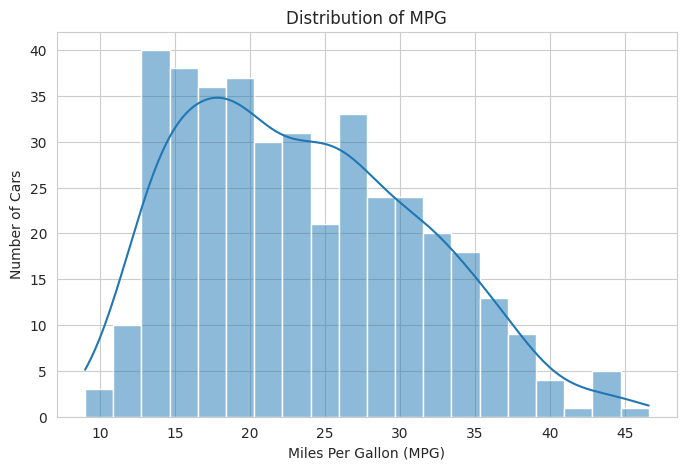

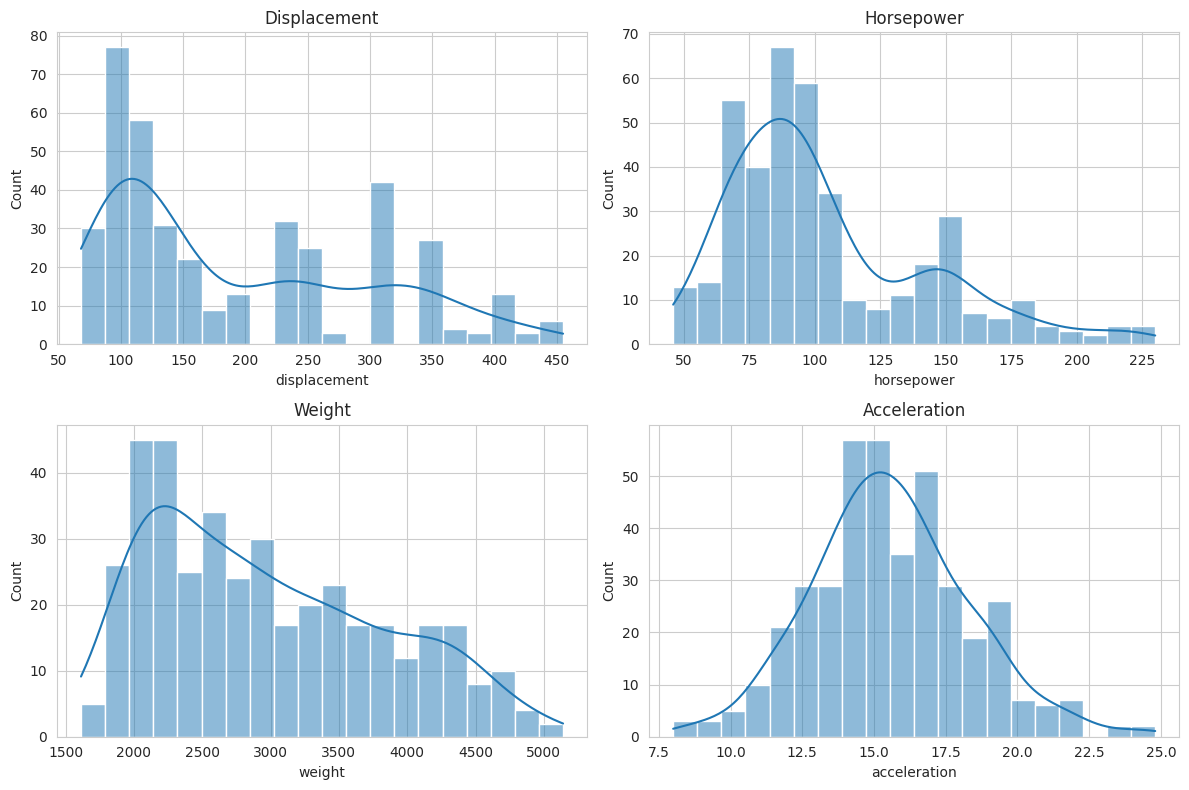

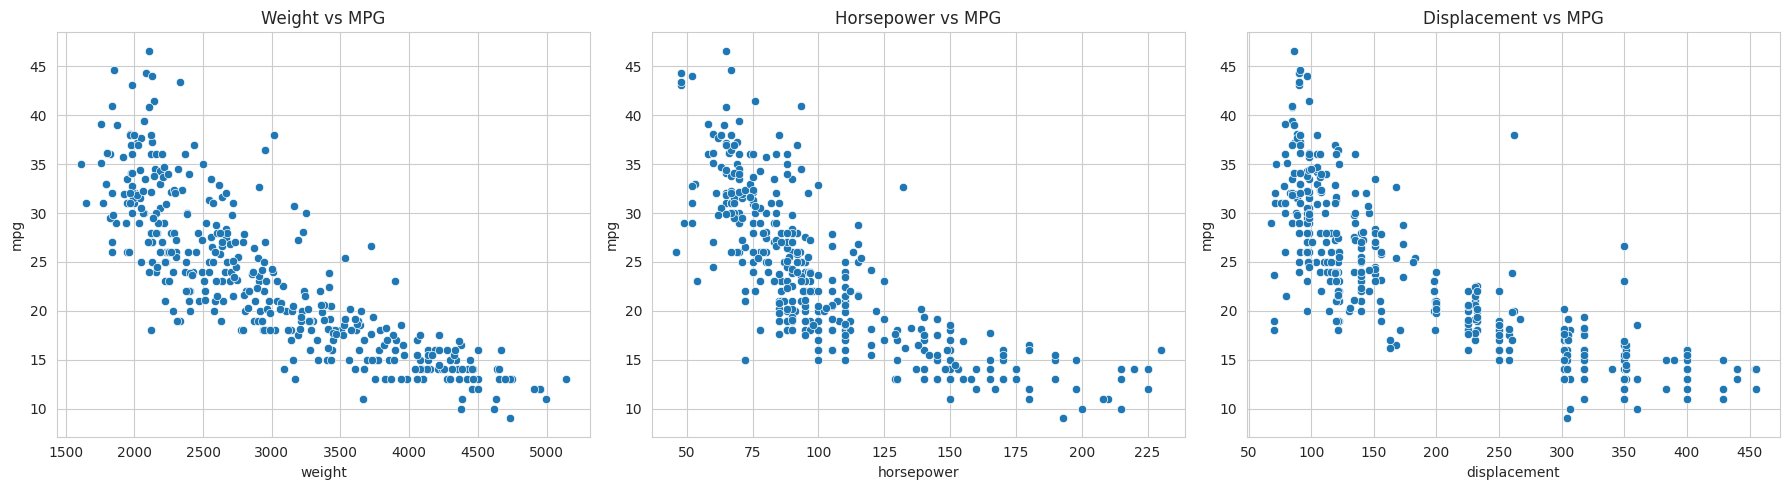

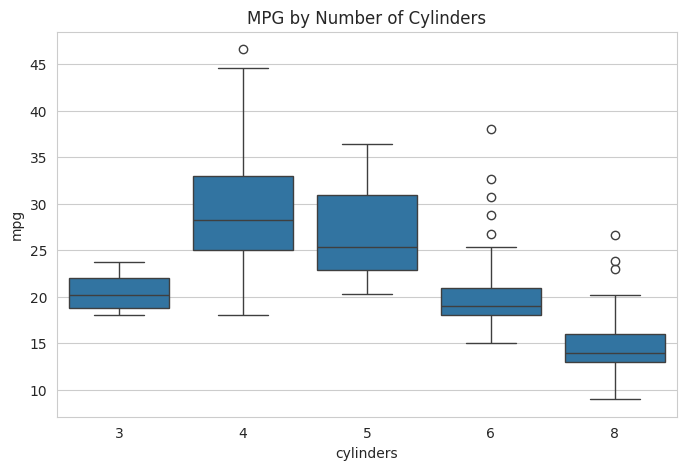

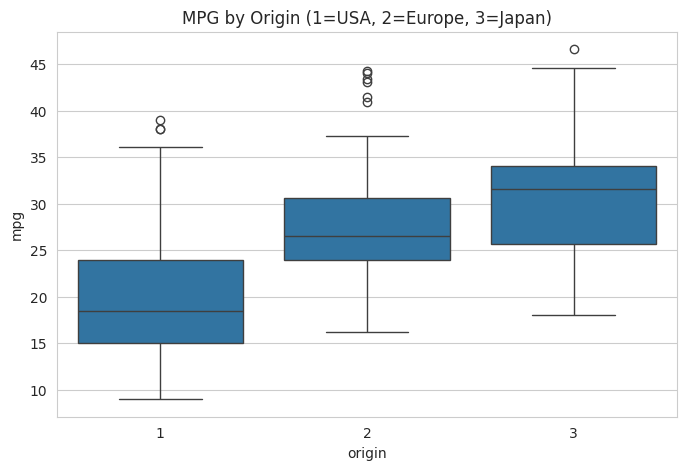

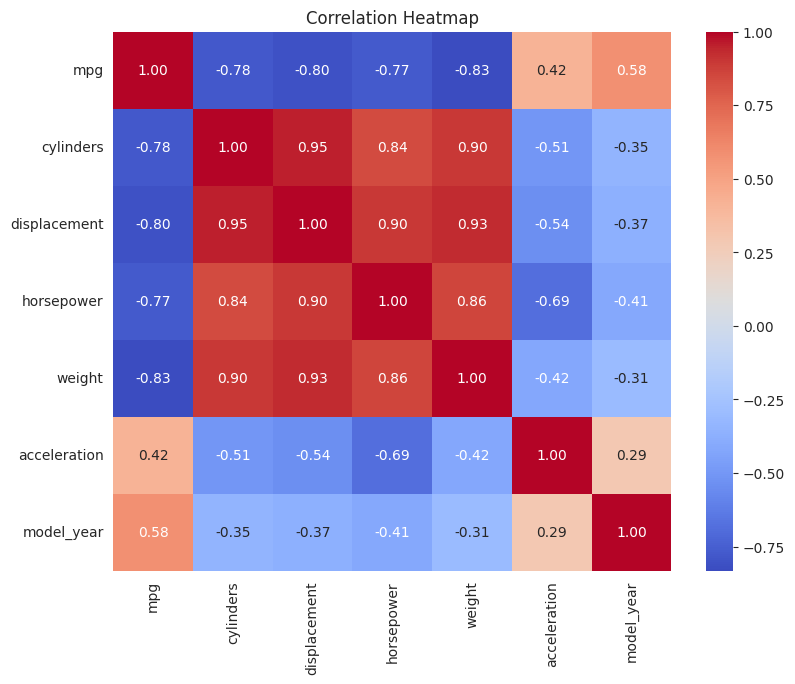

mpg             1.000000
model_year      0.579267
acceleration    0.420289
horsepower     -0.773453
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64

Car with the highest horsepower:


,116
mpg,16.0
cylinders,8
displacement,400.0
horsepower,230.0
weight,4278.0
acceleration,9.5
model_year,73
origin,1
car_name,pontiac grand prix



Car with the lowest MPG:


,28
mpg,9.0
cylinders,8
displacement,304.0
horsepower,193.0
weight,4732.0
acceleration,18.5
model_year,70
origin,1
car_name,hi 1200d



Car with the highest MPG:


,322
mpg,46.6
cylinders,4
displacement,86.0
horsepower,65.0
weight,2110.0
acceleration,17.9
model_year,80
origin,3
car_name,mazda glc


In [44]:
# ===== STEP 3: EXPLORATORY DATA ANALYSIS (EDA) =====

import matplotlib.pyplot as plt
import seaborn as sns

# Make our charts look a bit nicer by default
sns.set_style("whitegrid")

# ---- 1. Distribution of MPG ----
# A histogram shows us: are most cars fuel-efficient? gas guzzlers? mixed?
plt.figure(figsize=(8, 5))
sns.histplot(df['mpg'], bins=20, kde=True)
plt.title("Distribution of MPG")
plt.xlabel("Miles Per Gallon (MPG)")
plt.ylabel("Number of Cars")
plt.show()

# ---- 2. Distributions of other key vehicle characteristics ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['displacement'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title("Displacement")

sns.histplot(df['horsepower'], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title("Horsepower")

sns.histplot(df['weight'], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title("Weight")

sns.histplot(df['acceleration'], bins=20, kde=True, ax=axes[1,1])
axes[1,1].set_title("Acceleration")

plt.tight_layout()
plt.show()

# ---- 3. Relationship between MPG and at least 3 other variables ----
# Scatter plots: does MPG go up or down as these values increase?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='weight', y='mpg', data=df, ax=axes[0])
axes[0].set_title("Weight vs MPG")

sns.scatterplot(x='horsepower', y='mpg', data=df, ax=axes[1])
axes[1].set_title("Horsepower vs MPG")

sns.scatterplot(x='displacement', y='mpg', data=df, ax=axes[2])
axes[2].set_title("Displacement vs MPG")

plt.tight_layout()
plt.show()

# ---- 4. Compare MPG across meaningful groups ----
# Group 1: Cylinders (4, 6, 8 cylinder engines - do they differ in MPG?)
plt.figure(figsize=(8, 5))
sns.boxplot(x='cylinders', y='mpg', data=df)
plt.title("MPG by Number of Cylinders")
plt.show()

# Group 2: Origin (1 = USA, 2 = Europe, 3 = Japan, based on this dataset's documentation)
plt.figure(figsize=(8, 5))
sns.boxplot(x='origin', y='mpg', data=df)
plt.title("MPG by Origin (1=USA, 2=Europe, 3=Japan)")
plt.show()

# ---- 5. Correlation analysis ----
# This shows which numeric columns move together.
# +1 = strongly move together, -1 = strongly move opposite, 0 = no relationship
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print(corr_matrix['mpg'].sort_values(ascending=False))

# ---- 6. Identify an outlier / unusual observation ----
# Let's find the car with the highest horsepower relative to its MPG,
# or simply look at extreme values.
print("\nCar with the highest horsepower:")
display(df.loc[df['horsepower'].idxmax()])

print("\nCar with the lowest MPG:")
display(df.loc[df['mpg'].idxmin()])

print("\nCar with the highest MPG:")
display(df.loc[df['mpg'].idxmax()])

Average horsepower by origin:
origin_name
USA       118.638554
Europe     80.928571
Japan      79.835443
Name: horsepower, dtype: float64


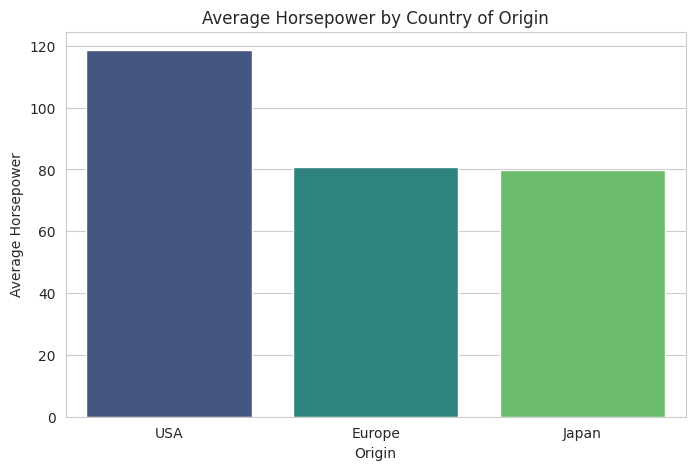

In [45]:
# ===== STEP 4: INDIVIDUAL ANALYSIS =====

# ---- My Question ----
# "Do cars from the USA, Europe, or Japan tend to have more powerful engines?"

# Why this question? Horsepower reflects engine power/performance,
# and different countries historically had different car-building priorities
# (e.g. American "muscle cars" vs Japanese fuel-efficient compacts).

# ---- Step 1: Map origin numbers to actual country names (easier to read) ----
origin_map = {1: 'USA', 2: 'Europe', 3: 'Japan'}
df['origin_name'] = df['origin'].map(origin_map)

# ---- Step 2: Average horsepower per origin ----
avg_hp_by_origin = df.groupby('origin_name')['horsepower'].mean().sort_values(ascending=False)
print("Average horsepower by origin:")
print(avg_hp_by_origin)

# ---- Step 3: Visualize it with a bar chart ----
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_hp_by_origin.index, y=avg_hp_by_origin.values, hue=avg_hp_by_origin.index, palette='viridis', legend=False)
plt.title("Average Horsepower by Country of Origin")
plt.xlabel("Origin")
plt.ylabel("Average Horsepower")
plt.show()

# ---- Step

In [46]:
# ===== STEP 5: EXPORT THE CLEANED DATASET =====

# Save the cleaned dataframe as a CSV file
df.to_csv('auto_mpg_cleaned.csv', index=False)

print("✅ Cleaned dataset saved as 'auto_mpg_cleaned.csv'")
print(f"Final shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Download it to your computer (only works in Google Colab)
from google.colab import files
files.download('auto_mpg_cleaned.csv')

✅ Cleaned dataset saved as 'auto_mpg_cleaned.csv'
Final shape: 398 rows, 10 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Key Findings from Auto MPG Analysis

1. Heavier cars use more fuel. Weight has the strongest link to MPG (-0.83) — the heavier the car, the worse its mileage.
2. Bigger engines also hurt fuel efficiency. Displacement (-0.80), cylinders (-0.78), and horsepower (-0.77) are all almost equally bad for MPG — basically, more powerful engines mean worse gas mileage.
3. Cars got more fuel-efficient over time. Model year has a decent positive link to MPG (0.58), meaning newer cars in this dataset tend to have better mileage than older ones — likely because of the 1970s fuel crisis pushing manufacturers to focus on efficiency.
4. Acceleration barely matters for MPG. It only has a weak positive link (0.42) — much weaker than weight or engine size. So how fast a car speeds up doesn't tell you much about its fuel efficiency.
5. The most powerful car in the dataset is a Pontiac Grand Prix — 230 horsepower, 8 cylinders, but only gets 16 MPG. A textbook example of "powerful but thirsty."
6. The least fuel-efficient car is the "hi 1200d" — only 9 MPG, 8 cylinders, and the heaviest car in the whole dataset at 4,732 lbs.
7. The most fuel-efficient car is a Mazda GLC — 46.6 MPG, just 4 cylinders, 65 horsepower, and a light 2,110 lbs. It's basically the opposite of the Pontiac — small, light, and efficient.
8. American cars have way more powerful engines than Japanese or European ones. On average: USA cars = 118.6 hp, Europe = 80.9 hp, Japan = 79.8 hp. USA cars are almost 50% more powerful than Japanese ones on average — this matches the old idea of American "muscle cars" versus fuel-focused Japanese cars.

In [47]:
# ===== TASK 2 - STEP 1: DATA PREPARATION =====

from sklearn.model_selection import train_test_split

# ---- 1. Load the cleaned dataset from Task 1 ----
# (You should already have 'df' in memory if you're continuing in the same notebook.
#  If starting fresh, uncomment the line below to reload your saved file)
# df = pd.read_csv('auto_mpg_cleaned.csv')

print("Columns in the dataset:")
print(df.columns.tolist())

# ---- 2. Prepare features (X) and target (y) ----
# 'y' is what we want to predict: MPG
# 'X' is everything we'll use to predict it

# Remove car_name (just text, not useful for prediction)
# Remove origin_name too if you added it earlier (we'll use the numeric 'origin' instead)
df_model = df.drop(columns=['car_name'])
if 'origin_name' in df_model.columns:
    df_model = df_model.drop(columns=['origin_name'])

# ---- 3. Convert 'origin' into one-hot encoded columns ----
# Before: origin = 1, 2, or 3 (looks like ranked numbers, but it's really just categories)
# After: three separate columns - origin_1, origin_2, origin_3 - each either True/False
df_model = pd.get_dummies(df_model, columns=['origin'], prefix='origin')

print("\nColumns after encoding origin:")
print(df_model.columns.tolist())

# ---- 4. Separate features (X) and target (y) ----
X = df_model.drop(columns=['mpg'])   # everything except mpg
y = df_model['mpg']                  # just mpg (what we're predicting)

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# ---- 5. Split into training (80%) and testing (20%) data ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} cars")
print(f"Testing set: {X_test.shape[0]} cars")

Columns in the dataset:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name', 'origin_name']

Columns after encoding origin:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_1', 'origin_2', 'origin_3']

Features (X) shape: (398, 9)
Target (y) shape: (398,)

Training set: 318 cars
Testing set: 80 cars


In [48]:
# ===== TASK 2 - STEP 2: LINEAR REGRESSION =====

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================================================
# PART 1: Single-feature model (weight only)
# =========================================================
print("===== SINGLE-FEATURE MODEL: Weight → MPG =====")

# We only use the 'weight' column this time
X_train_single = X_train[['weight']]
X_test_single = X_test[['weight']]

# Create and train the model
model_single = LinearRegression()
model_single.fit(X_train_single, y_train)

# Make predictions on the test data
y_pred_single = model_single.predict(X_test_single)

# Evaluate
mae_single = mean_absolute_error(y_test, y_pred_single)
mse_single = mean_squared_error(y_test, y_pred_single)
rmse_single = np.sqrt(mse_single)
r2_single = r2_score(y_test, y_pred_single)

print(f"MAE:  {mae_single:.3f}")
print(f"MSE:  {mse_single:.3f}")
print(f"RMSE: {rmse_single:.3f}")
print(f"R²:   {r2_single:.3f}")

# What did the model learn?
print(f"\nModel equation: MPG = {model_single.intercept_:.3f} + ({model_single.coef_[0]:.5f} × weight)")

# =========================================================
# PART 2: Multi-feature model (all features)
# =========================================================
print("\n\n===== MULTI-FEATURE MODEL: All features → MPG =====")

# Use ALL the columns in X_train / X_test this time
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Make predictions on the test data
y_pred_multi = model_multi.predict(X_test)

# Evaluate
mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print(f"MAE:  {mae_multi:.3f}")
print(f"MSE:  {mse_multi:.3f}")
print(f"RMSE: {rmse_multi:.3f}")
print(f"R²:   {r2_multi:.3f}")

# Which features mattered most? (bigger number = bigger influence on the prediction)
print("\nFeature importance (coefficients):")
for feature, coef in zip(X_train.columns, model_multi.coef_):
    print(f"  {feature}: {coef:.4f}")

# =========================================================
# PART 3: Compare the two models side by side
# =========================================================
print("\n\n===== COMPARISON: Single-feature vs Multi-feature =====")
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Single-feature (weight only)': [mae_single, mse_single, rmse_single, r2_single],
    'Multi-feature (all)': [mae_multi, mse_multi, rmse_multi, r2_multi]
})
display(comparison)

===== SINGLE-FEATURE MODEL: Weight → MPG =====
MAE:  3.118
MSE:  14.895
RMSE: 3.859
R²:   0.723

Model equation: MPG = 46.782 + (-0.00781 × weight)


===== MULTI-FEATURE MODEL: All features → MPG =====
MAE:  2.288
MSE:  8.339
RMSE: 2.888
R²:   0.845

Feature importance (coefficients):
  cylinders: -0.1657
  displacement: 0.0198
  horsepower: -0.0146
  weight: -0.0070
  acceleration: 0.0680
  model_year: 0.8260
  origin_1: -1.8727
  origin_2: 1.0742
  origin_3: 0.7984


===== COMPARISON: Single-feature vs Multi-feature =====


,Metric,Single-feature (weight only),Multi-feature (all)
0,MAE,3.117786,2.288159
1,MSE,14.894861,8.338657
2,RMSE,3.859386,2.887673
3,R²,0.722971,0.844910


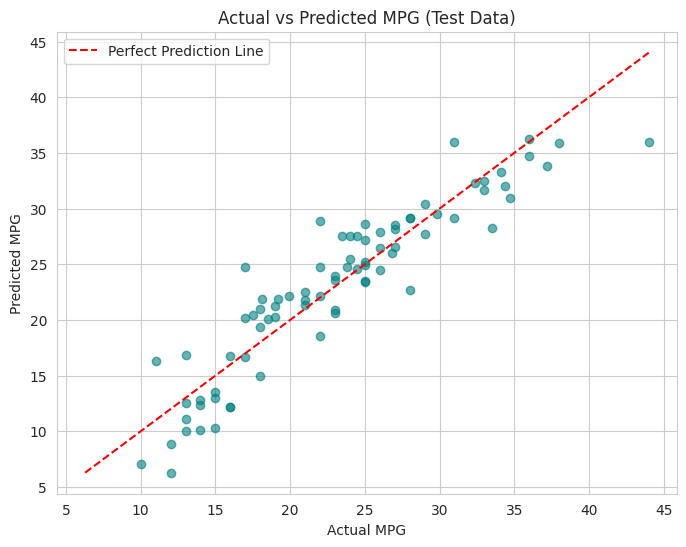

===== TRAINING vs TESTING PERFORMANCE =====


,Metric,Training Data,Testing Data
0,MAE,2.604740,2.288159
1,RMSE,3.369747,2.887673
2,R²,0.818885,0.844910



R² gap (Training - Testing): -0.0260
✅ The model shows a healthy balance - similar performance on both
   training and testing data, meaning it generalizes well.


In [49]:
# ===== TASK 2 - STEP 3: MODEL ANALYSIS =====

# ---- 1. Actual vs Predicted MPG plot (using the multi-feature model) ----
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.6, color='teal')

# Draw a perfect-prediction diagonal line for reference
min_val = min(y_test.min(), y_pred_multi.min())
max_val = max(y_test.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction Line')

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (Test Data)")
plt.legend()
plt.show()

# ---- 2. Compare performance on TRAINING data vs TESTING data ----
# This is the key check for overfitting/underfitting

# Predictions on training data (data the model already "saw")
y_train_pred = model_multi.predict(X_train)

# Metrics on TRAINING data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Metrics on TESTING data (already calculated in Step 2, just reprinting for clarity)
test_mae = mae_multi
test_rmse = rmse_multi
test_r2 = r2_multi

print("===== TRAINING vs TESTING PERFORMANCE =====")
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training Data': [train_mae, train_rmse, train_r2],
    'Testing Data': [test_mae, test_rmse, test_r2]
})
display(comparison_df)

# ---- 3. Automatic overfitting/underfitting check ----
r2_gap = train_r2 - test_r2
print(f"\nR² gap (Training - Testing): {r2_gap:.4f}")

if r2_gap > 0.1:
    print("⚠️ This suggests possible OVERFITTING - the model performs noticeably")
    print("   better on training data than on unseen test data.")
elif train_r2 < 0.6 and test_r2 < 0.6:
    print("⚠️ This suggests possible UNDERFITTING - the model performs poorly")
    print("   on both training and test data, meaning it's too simple to capture the pattern.")
else:
    print("✅ The model shows a healthy balance - similar performance on both")
    print("   training and testing data, meaning it generalizes well.")

Key Findings from Linear Regression Model

1. Using more features made the model much better. With just weight, the model explained 72% of MPG differences (R² = 0.723). Using all features together, that jumped to 84.5% (R² = 0.845) — a big improvement.
2. The final model is pretty accurate. On average, its MPG guesses are only off by about 2.29 MPG (MAE), which is quite good for real car data.
3. Model year and origin mattered more than expected. Newer cars were predicted to have higher MPG (model_year coefficient: +0.826), and American cars (origin_1) were predicted to have notably lower MPG (-1.87) compared to other countries.
4. Weight's effect shrank once combined with other features. On its own, weight was the strongest predictor. But once combined with things like displacement and cylinders (which move together with weight), its individual effect dropped to almost nothing (-0.0070).
5. The model isn't overfitting. Training R² (0.819) and testing R² (0.845) are very close to each other — meaning the model didn't just memorize the training cars, it actually learned a real pattern.
6. Overall, the model is well-balanced. Since it performs strongly and consistently on both training and testing data, it generalizes well to new, unseen cars.

Limitations of Linear Regression for This Dataset

1. Assumes straight-line relationships. Linear Regression assumes each feature affects MPG in a perfectly straight-line way, but real relationships (like weight vs MPG) might actually curve or bend, which this model can't capture.
2. Multicollinearity between features. Weight, displacement, and horsepower are all correlated with each other, not just with MPG. This makes it harder to trust the model's individual coefficients — like how weight's own effect (-0.0070) looked oddly small once combined with these related features.
3. Sensitive to outliers. A few unusual cars (like the very powerful Pontiac Grand Prix or the ultra-efficient Mazda GLC) can pull the model's line off-course more than they should.
4. Limited to the features it's given. Real-world fuel efficiency also depends on things like driving habits, tire pressure, and engine tuning — none of which are in this dataset, so the model can only ever be as good as the data it's fed.
Suggested Improvement

A good next step would be to try a more flexible model like Random Forest or Gradient Boosting. These models can capture non-linear relationships and typically perform better than plain Linear Regression on datasets like this one.